# RNE Nominal Oscillator Trace Task

This notebook reproduces the default oscillator objective used by `ReactionNetworkEvolution.jl` as a GenAI-Net task. The RNE nominal objective uses a fixed target trace and lets any species match it:

$$\mathcal{L}_{\mathrm{RNE}} = \min_j \sum_{i=1}^{11} |x_j(t_i) - y_i|,$$

with $t_i = \mathrm{linspace}(0, 1.25, 11)$ and $y=(5,30,5,30,5,30,5,30,5,30,5)$.

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

print("Python:", sys.version.split()[0])
print("CWD:", os.getcwd())

Python: 3.10.12
CWD: /local0/rossin/git/GenAI-Net/apps


## 1) Imports

In [2]:
from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)
from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library
from RL4CRN.utils.default_tasks.RNEOscillatorTraceTaskKind import (
    RNEOscillatorTraceTaskKind,
    RNE_OSCILLATOR_TARGET,
    RNE_OSCILLATOR_TIME,
)

## 2) Autonomous 3-species template

RNE's default oscillator search is autonomous: no inputs, three species, five initial reactions. Here the template has no reactions; GenAI-Net adds up to five reactions from the same second-order mass-action library.

In [3]:
cfg = Configurator.preset("paper")
cfg.solver.algorithm = "CVODE"
cfg.solver.rtol = 1e-10
cfg.solver.atol = 1e-10

species_labels = ["X_1", "X_2", "X_3"]
crn, species_labels = build_simple_IOCRN(
    species=species_labels,
    production_input_map={},
    output_species=species_labels,
    solver=cfg.solver,
)

library_components = build_MAK_library(crn, species_labels, order=2)
library, M, K, masks = library_components

print("Template CRN built.")
print(" - num_inputs:", crn.num_inputs)
print(" - species:", crn.species_labels)
print(" - template reactions:", crn.num_reactions)
print(" - library reactions:", M)

Template CRN built.
 - num_inputs: 0
 - species: ['X_1', 'X_2', 'X_3']
 - template reactions: 0
 - library reactions: 91


## 3) Define the nominal RNE oscillator-trace task

In [4]:
RNEOscillatorTraceTaskKind.pretty_help()

### TaskKind `rne_oscillator_trace`

**Required params**
- (none)

**Optional params**
- `time_horizon`: 1D array of target times; defaults to linspace(0, 1.25, 11)
- `target_trace`: 1D array; defaults to [5, 30, ..., 30, 5]
- `ic`: IC spec; RNE default is ('values', [[1.0, 5.0, 9.0]])
- `u_list`: explicit input scenarios; default is one empty input vector
- `normalize`: bool; divide by number of target points (default False)
- `LARGE_NUMBER`: float divergence threshold (default 1e4)

**Notes**
- The loss is min_j sum_i |x_j(t_i) - y_i|, matching the inverse of RNE's default oscillator
  fitness. The best species is recorded in last_task_info['best_species_label'].


In [5]:
task = make_task(
    template_crn=crn,
    library_components=library_components,
    kind="rne_oscillator_trace",
    species_labels=species_labels,
    params={
        "time_horizon": RNE_OSCILLATOR_TIME,
        "target_trace": RNE_OSCILLATOR_TARGET,
        "ic": ("values", [[1.0, 5.0, 9.0]]),
        "u_list": [np.asarray([], dtype=np.float32)],
        "LARGE_NUMBER": 1e4,
        "LARGE_PENALTY": 1e4,
        "normalize": False,
    },
)

print_task_summary(task)
loss, info = task.compute_reward(crn)
print("Zero-reaction template loss:", loss)
print("Best matching species:", info.get("best_species_label"))

Task: rne_oscillator_trace
time_horizon: (11,) [0..1.25]
num scenarios: 1
first 1 u: [array([], dtype=float32)]

Zero-reaction template loss: 125.0
Best matching species: X_2


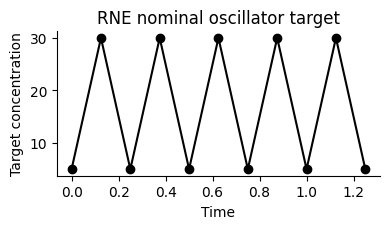

In [6]:
fig, ax = plt.subplots(figsize=(4.0, 2.4))
ax.plot(RNE_OSCILLATOR_TIME, RNE_OSCILLATOR_TARGET, "o-", color="black")
ax.set_xlabel("Time")
ax.set_ylabel("Target concentration")
ax.set_title("RNE nominal oscillator target")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## 4) Training configuration

In [7]:
cfg.train.max_added_reactions = 5
cfg.train.epochs = 801
cfg.train.batch_size = 100
cfg.train.render_every = 50
cfg.train.hall_of_fame_size = 50
cfg.train.seed = 0
cfg.agent.risk_scheduler["risk"] = 0.9
cfg.agent.learning_rate = 1e-4
cfg.agent.entropy_scheduler["entropy"] = 0.001
cfg.agent.entropy_scheduler["structure"] = 0.001
cfg.agent.entropy_scheduler["continuous"] = 0.3
cfg.agent.entropy_scheduler["structure"] = 4.0

cfg.render.n_best = 20
cfg.render.disregarded_percentage = 0.9
cfg.render.mode = {
    "style": "logger",
    "task": "transients",
    "format": "image",
    "topology": True,
}

cfg.describe()

{'task': None,
 'solver': {'algorithm': 'CVODE', 'rtol': 1e-10, 'atol': 1e-10},
 'train': {'epochs': 801,
           'max_added_reactions': 5,
           'render_every': 50,
           'hall_of_fame_size': 50,
           'batch_multiplier': 10,
           'seed': 0,
           'n_cpus': None,
           'batch_size': 100},
 'policy': {'width': 1024,
            'depth': 5,
            'deep_layer_size': 10240,
            'continuous_distribution': {'type': 'lognormal_1D'},
            'entropy_weights_per_head': {'structure': 2.0, 'continuous': 1.0, 'discrete': 0.0, 'input_influence': 0.0},
            'ordering_enabled': False,
            'constraint_strength': inf,
            'zero_reaction_idx': None,
            'stop_flag': False},
 'agent': {'learning_rate': 0.0001,
           'entropy_scheduler': {'entropy_weight': 0.001,
                                 'topk_entropy_weight': 1.0,
                                 'remainder_entropy_weight': 1.0,
                             

## 5) Create trainer

In [8]:
from datetime import datetime
from RL4CRN.utils.input_interface import make_session_and_trainer

logger = None
if os.environ.get("COMET_API_KEY") and os.environ.get("COMET_WORKSPACE"):
    from pytorch_lightning.loggers import CometLogger
    task_name = "Oscillator_RNE_like"
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    logger = CometLogger(
        api_key=os.environ["COMET_API_KEY"],
        project=task_name,
        workspace=os.environ["COMET_WORKSPACE"],
        name=f"{task_name}_{timestamp}",
    ).experiment


trainer = make_session_and_trainer(cfg, task, logger=logger)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/redsnic/oscillator-rne-like/ae11eab2e30a4b429cd1f8315f4276f8



## 6) Train and checkpoint

In [9]:
checkpoint_path = "rne_nominal_oscillator_trace_chkpt.pkl"
trainer.run(epochs=cfg.train.epochs, checkpoint_path=checkpoint_path)

[epoch 0] best loss=124 | median loss=129.8


/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/environments/environment.py:232: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/environments/environment.py:232: UserWarning: The figure layout has changed to tight
  fig.tight_layout(

Saved checkpoint: rne_nominal_oscillator_trace_chkpt.pkl
[epoch 50] best loss=120.7 | median loss=132.7


/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/environments/environment.py:232: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/environments/environment.py:232: UserWarning: The figure layout has changed to tight
  fig.tight_layout(

Saved checkpoint: rne_nominal_oscillator_trace_chkpt.pkl

[cvHandleFailure, Error: -15] At t = 1.03476730954795, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 1.15872546173284, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 1.19397467058883, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 1.09387923968824, unable to satisfy inequality constraints.

[epoch 100] best loss=120.3 | median loss=122.3


...

Saved checkpoint: rne_nominal_oscillator_trace_chkpt.pkl

[cvHandleFailure, Error: -15] At t = 0.548910747629392, unable to satisfy inequality constraints.


[CVode, Error: -1] At t = 1.24871225885286, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 1.11115973810792, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 0.728108069537954, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 0.998573707502451, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 0.0651945767790967, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 0.0761658917189469, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 1.12302543120293, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 0.851953125539076, mxstep steps taken before reaching tout.


[cvHandleFailure, Error: -15] At t = 0.359121704830967, unable to satisfy inequality constraints.


[CVode, Error: -1] At t = 0.11959699763

/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/environments/environment.py:232: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/environments/environment.py:232: UserWarning: The figure layout has changed to tight
  fig.tight_layout(

Saved checkpoint: rne_nominal_oscillator_trace_chkpt.pkl

[CVode, Error: -1] At t = 0.992849003760955, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 1.23368461238284, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 0.0656364065763158, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 1.09855035788841, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 0.860981622441672, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 1.23405041262026, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 1.24856539420292, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 0.108084897597484, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 0.0577730854791472, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 0.0960735141930902, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 1.24984192425342, mxstep steps taken 

/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/environments/environment.py:232: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))
/local0/rossin/git/GenAI-Net/.venv/lib/python3.10/site-packages/RL4CRN/environments/environment.py:232: UserWarning: The figure layout has changed to tight
  fig.tight_layout(

Saved checkpoint: rne_nominal_oscillator_trace_chkpt.pkl


## 7) Inspect best CRN and trajectory

In [10]:
best_crn = trainer.s.hall_of_fame[0].state
best_loss, best_info = task.compute_reward(best_crn)
print("Best loss:", best_loss)
print("Best matching species:", best_info.get("best_species_label"))
print(best_crn)

AttributeError: 'Session' object has no attribute 'hall_of_fame'

In [ ]:
t, x_list, _, _ = best_crn.transient_response(
    task.u_list,
    task.ic.get_ic(best_crn),
    task.time_horizon,
    LARGE_NUMBER=task.LARGE_NUMBER,
)
x = x_list[0]

fig, ax = plt.subplots(figsize=(4.3, 2.8))
ax.plot(RNE_OSCILLATOR_TIME, RNE_OSCILLATOR_TARGET, "o-", color="black", label="RNE target")
for i, label in enumerate(best_crn.species_labels):
    lw = 2.2 if label == best_info.get("best_species_label") else 1.0
    alpha = 1.0 if label == best_info.get("best_species_label") else 0.45
    ax.plot(t, x[i], "o--", label=label, linewidth=lw, alpha=alpha)
ax.set_xlabel("Time")
ax.set_ylabel("Concentration")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()